In [ ]:
# =====  Setup (Colab/Drive + imports) =====
from google.colab import drive
drive.mount('/content/drive')

import os, json, math
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

PROJ = "/content/drive/MyDrive/Imbalance"
os.makedirs(os.path.join(PROJ, "figures"), exist_ok=True)
os.makedirs(os.path.join(PROJ, "ckpts"), exist_ok=True)
os.makedirs(os.path.join(PROJ, "metrics"), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Mounted at /content/drive
Device: cuda


In [ ]:
# ===== Config (split + GAN + classifier) =====
CONFIG = {
    "split_key": "ss",    # "lt", "ss", or "as"

    # GAN config
    "z_dim": 128,
    "g_channels": 384,    # slightly bigger generator
    "d_channels": 128,
    "gan_batch_size": 64,
    "gan_epochs": 300,     # base; small classes get more

    # classifier config
    "clf_batch_size": 128,
    "clf_epochs": 50,
    "clf_lr": 0.1,
}

GAN_CKPT_DIR = os.path.join(PROJ, "ckpts_gan", f"sngan_{CONFIG['split_key']}")
os.makedirs(GAN_CKPT_DIR, exist_ok=True)

print("Using split:", CONFIG["split_key"])
print("GAN ckpts:", GAN_CKPT_DIR)


Using split: ss
GAN ckpts: /content/drive/MyDrive/Imbalance/ckpts_gan/sngan_ss


In [ ]:
# =====  CIFAR-10 (classifier datasets) =====
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),  # -> [-1,1]
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])

data_root = os.path.join(PROJ, "dataset_cache")

train_ds = datasets.CIFAR10(root=data_root, train=True,
                            download=True, transform=train_tf)
test_ds  = datasets.CIFAR10(root=data_root, train=False,
                            download=True, transform=test_tf)

class_labels = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

print("Train size:", len(train_ds), " Test size:", len(test_ds))


Train size: 50000  Test size: 10000


In [ ]:
# =====  Load LT/SS/AS split indices =====
def load_split(split_key):
    """
    Expect: PROJ/splits/{split_key}.json
    with keys: {"indices":[...], "counts":{...}}
    """
    path = os.path.join(PROJ, "splits", f"{split_key}.json")
    assert os.path.exists(path), f"Missing split file: {path}"
    with open(path, "r") as f:
        d = json.load(f)
    return d["indices"], d.get("counts", None)

SPLIT_INDICES, SPLIT_COUNTS = load_split(CONFIG["split_key"])
print(f"Loaded split '{CONFIG['split_key'].upper()}': {len(SPLIT_INDICES)} images")

targets_full = np.array(train_ds.targets)
class_to_indices = {c: [] for c in range(10)}
for idx in SPLIT_INDICES:
    c = int(targets_full[idx])
    class_to_indices[c].append(idx)

class_counts = {c: len(class_to_indices[c]) for c in range(10)}
print("Per-class counts (split):", class_counts)


Loaded split 'SS': 27500 images
Per-class counts (split): {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}


In [ ]:
# ===== GAN-specific dataset (simpler augment) =====
gan_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5)),  # -> [-1,1]
])

gan_train_ds = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False,
    transform=gan_tf,
)

targets_gan = np.array(gan_train_ds.targets)
class_to_indices_gan = {c: [] for c in range(10)}
for idx in SPLIT_INDICES:
    c = int(targets_gan[idx])
    class_to_indices_gan[c].append(idx)

gan_counts = {c: len(class_to_indices_gan[c]) for c in range(10)}
print("GAN per-class counts:", gan_counts)


GAN per-class counts: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}


In [ ]:
# ===== SNGAN Generator & Discriminator =====
def snlinear(in_features, out_features):
    return nn.utils.spectral_norm(nn.Linear(in_features, out_features))

def snconv2d(in_channels, out_channels, kernel_size, stride=1, padding=0):
    return nn.utils.spectral_norm(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
    )

class SNGANGenerator(nn.Module):
    """
    DCGAN-style generator (no spectral norm, with BatchNorm)
    """
    def __init__(self, z_dim=128, g_channels=384):
        super().__init__()
        self.z_dim = z_dim

        self.fc = nn.Linear(z_dim, g_channels * 4 * 4)

        self.net = nn.Sequential(
            nn.BatchNorm2d(g_channels),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),             # 4 -> 8
            nn.Conv2d(g_channels, g_channels // 2, 3, 1, 1),
            nn.BatchNorm2d(g_channels // 2),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),             # 8 -> 16
            nn.Conv2d(g_channels // 2, g_channels // 4, 3, 1, 1),
            nn.BatchNorm2d(g_channels // 4),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),             # 16 -> 32
            nn.Conv2d(g_channels // 4, 3, 3, 1, 1),
            nn.Tanh(),                               # [-1,1]
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), -1, 4, 4)
        return self.net(x)


class SNGANDiscriminator(nn.Module):
    """
    Spectral Norm on all layers (SNGAN-style hinge loss)
    """
    def __init__(self, d_channels=128):
        super().__init__()
        self.net = nn.Sequential(
            snconv2d(3, d_channels, 3, 2, 1),         # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),

            snconv2d(d_channels, d_channels * 2, 3, 2, 1),  # 16 -> 8
            nn.LeakyReLU(0.2, inplace=True),

            snconv2d(d_channels * 2, d_channels * 4, 3, 2, 1),  # 8 -> 4
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            snlinear(d_channels * 4 * 4 * 4, 1),
        )

    def forward(self, x):
        return self.net(x).view(-1)   # (B,)


In [ ]:
# =====  Train SNGAN for a single class (hinge + preview) =====
import torch.optim as optim

def train_sngan_for_class(class_id, epochs=None, batch_size=None):
    z_dim = CONFIG["z_dim"]
    g_channels = CONFIG["g_channels"]
    d_channels = CONFIG["d_channels"]

    n_real = len(class_to_indices_gan[class_id])

    # more epochs + smaller batch for minority classes
    if epochs is None:
        epochs = 300 if n_real < 400 else CONFIG["gan_epochs"]
    if batch_size is None:
        batch_size = 32 if n_real < 400 else CONFIG["gan_batch_size"]

    indices = class_to_indices_gan[class_id]
    subset = Subset(gan_train_ds, indices)
    loader = DataLoader(subset, batch_size=batch_size,
                        shuffle=True, num_workers=2, drop_last=True)

    print(f"[Class {class_id} - {class_labels[class_id]}] "
          f"{len(subset)} real images, epochs={epochs}, batch={batch_size}")

    G = SNGANGenerator(z_dim=z_dim, g_channels=g_channels).to(device)
    D = SNGANDiscriminator(d_channels=d_channels).to(device)

    opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.0, 0.9))
    opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.0, 0.9))

    def sample_z(n):
        return torch.randn(n, z_dim, device=device)

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        for real, _ in loader:
            real = real.to(device)  # [-1,1]

            # ----- Train D (hinge) -----
            opt_D.zero_grad()
            z = sample_z(real.size(0))
            fake = G(z).detach()
            d_real = D(real)
            d_fake = D(fake)
            loss_D = torch.mean(nn.ReLU()(1.0 - d_real)) + \
                     torch.mean(nn.ReLU()(1.0 + d_fake))
            loss_D.backward()
            opt_D.step()

            # ----- Train G -----
            opt_G.zero_grad()
            z = sample_z(real.size(0))
            fake = G(z)
            d_fake = D(fake)
            loss_G = -torch.mean(d_fake)
            loss_G.backward()
            opt_G.step()

        # preview every 20 epochs and last
        if epoch % 20 == 0 or epoch == epochs:
            G.eval()
            with torch.no_grad():
                z = sample_z(64)
                fake = G(z)                    # [-1,1]
                fake_vis = (fake + 1.0) / 2.0  # [0,1]

            grid = make_grid(fake_vis.cpu(), nrow=8, padding=2)
            np_grid = grid.permute(1, 2, 0).numpy()

            plt.figure(figsize=(6, 6))
            plt.title(f"Class {class_id} ({class_labels[class_id]}) - epoch {epoch}")
            plt.axis("off")
            plt.imshow(np_grid)
            plt.show()

            print(f"[Class {class_id}] Epoch {epoch}/{epochs} "
                  f"| loss_D={loss_D.item():.3f} loss_G={loss_G.item():.3f}")

    ckpt_path = os.path.join(GAN_CKPT_DIR, f"G_class_{class_id}.pth")
    torch.save(G.state_dict(), ckpt_path)
    print(f"[Class {class_id}] Saved generator to {ckpt_path}")
    return ckpt_path


In [ ]:
# =====  Train SNGAN for all classes (optional) =====
for c in range(10):
    print("=" * 70)
    print(f"Training SNGAN for class {c} ({class_labels[c]})")
    train_sngan_for_class(c)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ===== Helpers for synthesis & dataset =====
class RealAndSyntheticDataset(Dataset):
    """
    Combines:
      - real images from SS split (SPLIT_INDICES)
      - synthetic images generated by per-class SNGANs
    """
    def __init__(self, base_ds, real_indices, synth_images, synth_labels):
        self.base_ds = base_ds
        self.real_indices = list(real_indices)
        self.synth_images = synth_images
        self.synth_labels = synth_labels
        self.real_len = len(self.real_indices)
        self.synth_len = len(self.synth_images)

    def __len__(self):
        return self.real_len + self.synth_len

    def __getitem__(self, i):
        if i < self.real_len:
            x, y = self.base_ds[self.real_indices[i]]  # already [-1,1]
            return x, y
        else:
            j = i - self.real_len
            x = self.synth_images[j]                   # [-1,1]
            y = int(self.synth_labels[j])
            return x, y


def load_generator_for_class(class_id):
    z_dim = CONFIG["z_dim"]
    g_ch = CONFIG["g_channels"]
    G = SNGANGenerator(z_dim=z_dim, g_channels=g_ch)
    ckpt_path = os.path.join(GAN_CKPT_DIR, f"G_class_{class_id}.pth")
    assert os.path.exists(ckpt_path), f"Missing generator ckpt: {ckpt_path}"
    G.load_state_dict(torch.load(ckpt_path, map_location=device))
    G.to(device)
    G.eval()
    return G


In [ ]:
# =====  Load SS baseline DenseNet for filtering (optional) =====
from torchvision.models import densenet121

def make_densenet121(num_classes=10):
    # start from torchvision densenet
    model = densenet121(weights=None)

    # *** CIFAR-10 style modifications ***
    # 32x32 images → use 3x3 conv, stride 1, padding 1
    import torch.nn as nn
    model.features.conv0 = nn.Conv2d(
        3, 64, kernel_size=3, stride=1, padding=1, bias=False
    )
    # remove the 3x3 max-pool (optional but typical for CIFAR)
    model.features.pool0 = nn.Identity()

    # classifier for 10 classes
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    return model.to(device)


def load_SS_baseline_for_filter(ckpt_name="densenet121_SS_baseline.pt"):
    """
    If you don't have this baseline yet, you can:
    - either train it, or
    - skip filtering by setting baseline_model = None
    """
    model = make_densenet121(num_classes=10)
    ckpt_path = os.path.join(PROJ, "ckpts", ckpt_name)
    assert os.path.exists(ckpt_path), f"Missing baseline checkpoint: {ckpt_path}"
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device)
    model.eval()
    print("Loaded SS baseline from:", ckpt_path)
    return model

# Try to load baseline; if missing, we continue without filter
try:
    baseline_model = load_SS_baseline_for_filter("densenet121_SS_baseline.pt")
except AssertionError as e:
    print(e)
    print("Continuing WITHOUT filtering GAN images.")
    baseline_model = None



Missing baseline checkpoint: /content/drive/MyDrive/Imbalance/ckpts/densenet121_SS_baseline.pt
Continuing WITHOUT filtering GAN images.


In [ ]:
# =====  Generate GAN images with optional filtering =====
from torch.nn.functional import softmax

def generate_for_class(
    G,
    class_id,
    n_samples,
    batch_size=128,
    filter_model=None,
    filter_thresh=0.7,
    max_loops=50,
):
    """
    Generate n_samples synthetic images for one class.

    If filter_model is given:
      - keep only images where filter_model predicts class_id
      - with probability >= filter_thresh.
    """
    imgs = []
    labels = []
    collected = 0
    loops = 0

    while collected < n_samples and loops < max_loops:
        loops += 1

        b = min(batch_size, n_samples - collected)
        if filter_model is not None:
            b = b * 2  # oversample to survive filtering

        z = torch.randn(b, CONFIG["z_dim"], device=device)
        with torch.no_grad():
            fake = G(z)   # [-1,1]

        if filter_model is not None:
            with torch.no_grad():
                logits = filter_model(fake)
                probs = softmax(logits, dim=1)
                conf, pred = probs.max(dim=1)
                mask = (pred == class_id) & (conf >= filter_thresh)

            fake = fake[mask]
            keep = fake.size(0)
            if keep == 0:
                continue
        else:
            keep = fake.size(0)

        fake = fake[: max(0, min(keep, n_samples - collected))]
        if fake.size(0) == 0:
            continue

        imgs.append(fake.cpu())
        labels.append(torch.full((fake.size(0),), class_id, dtype=torch.long))
        collected += fake.size(0)

    if len(imgs) == 0:
        print(f"[WARN] No synthetic samples kept for class {class_id}")
        return torch.empty(0, 3, 32, 32), torch.empty(0, dtype=torch.long)

    imgs = torch.cat(imgs, dim=0)
    labels = torch.cat(labels, dim=0)
    print(f"Class {class_id}: collected {imgs.size(0)} filtered GAN samples")
    return imgs, labels


In [ ]:
# =====  Build SNGAN-balanced dataset with soft top-up =====
def build_balanced_dataset_with_sngan(
    topup_factor=0.1,
    filter_model=baseline_model,
    filter_thresh=0.8,
):

    max_count = max(class_counts.values())
    target_per_class = {}

    for c in range(10):
        n_real = class_counts[c]
        target = int(n_real + topup_factor * (max_count - n_real))
        target_per_class[c] = target

    print("max_count:", max_count)
    print("topup_factor:", topup_factor)
    print("target_per_class:", target_per_class)

    all_real_indices = []
    all_synth_images = []
    all_synth_labels = []

    for c in range(10):

        real_indices_c = class_to_indices[c]
        n_real = len(real_indices_c)

        # ALWAYS define need before printing
        target = target_per_class[c]
        need = max(0, target - n_real)
        n_real = len(real_indices_c)

        if n_real > 500:
          target = n_real

        else:
          target = int(n_real + topup_factor * (max_count - n_real))


        print(f"Class {c} ({class_labels[c]}): real={n_real}, "
              f"target={target}, need_synth={need}")

        all_real_indices.extend(real_indices_c)

        if need > 0:
            G_c = load_generator_for_class(c)
            synth_imgs_c, synth_labels_c = generate_for_class(
                G_c,
                c,
                need,
                batch_size=128,
                filter_model=filter_model,
                filter_thresh=filter_thresh,
            )
            if synth_imgs_c.size(0) > 0:
                all_synth_images.append(synth_imgs_c)
                all_synth_labels.append(synth_labels_c)

    if len(all_synth_images) > 0:
        all_synth_images = torch.cat(all_synth_images, dim=0)
        all_synth_labels = torch.cat(all_synth_labels, dim=0)
    else:
        all_synth_images = torch.empty(0, 3, 32, 32)
        all_synth_labels = torch.empty(0, dtype=torch.long)

    print("Total real samples:", len(all_real_indices))
    print("Total synthetic samples:", len(all_synth_images))

    balanced_ds = RealAndSyntheticDataset(
        base_ds=train_ds,
        real_indices=all_real_indices,
        synth_images=all_synth_images,
        synth_labels=all_synth_labels,
    )
    return balanced_ds


In [ ]:
# =====  Make train loader from SNGAN-balanced dataset =====
balanced_ds = build_balanced_dataset_with_sngan(
    topup_factor=0.5,          # try 0.3, 0.5, 0.7, etc.
    filter_model=baseline_model,  # or None if you don't want filtering
    filter_thresh=0.8,
)

sngan_train_loader = DataLoader(
    balanced_ds,
    batch_size=CONFIG["clf_batch_size"],
    shuffle=True,
    num_workers=2,
)

print("Balanced dataset size:", len(balanced_ds))


max_count: 5000
topup_factor: 0.5
target_per_class: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 2750, 6: 2750, 7: 2750, 8: 2750, 9: 2750}
Class 0 (airplane): real=5000, target=5000, need_synth=0
Class 1 (automobile): real=5000, target=5000, need_synth=0
Class 2 (bird): real=5000, target=5000, need_synth=0
Class 3 (cat): real=5000, target=5000, need_synth=0
Class 4 (deer): real=5000, target=5000, need_synth=0
Class 5 (dog): real=500, target=2750, need_synth=2250
Class 5: collected 2250 filtered GAN samples
Class 6 (frog): real=500, target=2750, need_synth=2250
Class 6: collected 2250 filtered GAN samples
Class 7 (horse): real=500, target=2750, need_synth=2250
Class 7: collected 2250 filtered GAN samples
Class 8 (ship): real=500, target=2750, need_synth=2250
Class 8: collected 2250 filtered GAN samples
Class 9 (truck): real=500, target=2750, need_synth=2250
Class 9: collected 2250 filtered GAN samples
Total real samples: 27500
Total synthetic samples: 11250
Balanced dataset size: 38

In [ ]:
# ===== Train & evaluate DenseNet on SNGAN-balanced data =====
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)
import pandas as pd

def run_sngan_experiment_SS_densenet():
    print("============== SS | densenet121 | sngan ===============")

    # ----- train -----
    model = make_densenet121(num_classes=10)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=CONFIG["clf_lr"],
        momentum=0.9,
        weight_decay=5e-4,
    )
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[30, 40], gamma=0.1
    )
    criterion = nn.CrossEntropyLoss()

    epochs = CONFIG["clf_epochs"]
    print("--- SS| densenet121 | sngan (CE loss) ---")
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for x, y in sngan_train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total * 100.0
        print(f"Ep {epoch:02d} | train_loss={train_loss:.3f} acc={train_acc:.1f}%")

    # ----- test -----
    test_loader = DataLoader(test_ds, batch_size=256,
                             shuffle=False, num_workers=2)
    model.eval()
    all_y, all_pred = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_pred.append(preds)
            all_y.append(y.numpy())

    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)

    report = classification_report(
        all_y, all_pred, digits=2, target_names=class_labels
    )
    macro_f1 = f1_score(all_y, all_pred, average="macro")
    bal_acc = balanced_accuracy_score(all_y, all_pred)
    overall_acc = (all_y == all_pred).mean()

    print()
    print("---- Classification report: SS | densenet121 | sngan ----")
    print(report)
    print(f"Final test -- Acc {overall_acc*100:.2f}% | "
          f"Macro-F1 {macro_f1*100:.2f}% | Balanced Acc {bal_acc*100:.2f}%")

    # ----- save report & model -----
    txt_path = os.path.join(
        PROJ, "metrics", "densenet121_SS_sngan_report.txt"
    )
    with open(txt_path, "w") as f:
        f.write(report)
    print("Saved report to:", txt_path)

    ckpt_path = os.path.join(
        PROJ, "ckpts", "densenet121_SS_sngan.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    print("Saved model to:", ckpt_path)

    # ----- confusion matrix -----
    cm = confusion_matrix(all_y, all_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_labels)),
        yticks=np.arange(len(class_labels)),
        xticklabels=class_labels,
        yticklabels=class_labels,
        ylabel="True",
        xlabel="Predicted",
        title="Confusion Matrix — SS densenet121 (sngan)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()

    # ----- per-class bar plot -----
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_y, all_pred, labels=range(10)
    )

    x = np.arange(len(class_labels))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.bar(x - width, prec, width, label="Precision")
    ax.bar(x,         rec,  width, label="Recall")
    ax.bar(x + width, f1,   width, label="F1")
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title("Per-class — SS densenet121 (sngan)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ----- CSV summary -----
    csv_path = os.path.join(PROJ, "metrics", "summary_sngan.csv")
    row = {
        "Scenario": "SS",
        "Model": "densenet121",
        "Loader": "sngan",
        "Gamma": "",
        "AlphaMode": "",
        "Macro-F1 (%)": macro_f1 * 100.0,
        "Balanced Acc (%)": bal_acc * 100.0,
        "Overall Acc (%)": overall_acc * 100.0,
    }

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])

    df.to_csv(csv_path, index=False)
    print("Updated:", csv_path)

    return model, (all_y, all_pred)


============== SS | densenet121 | sngan ===============
--- SS| densenet121 | sngan (CE loss) ---
Ep 01 | train_loss=1.260 acc=56.2%
Ep 02 | train_loss=0.810 acc=71.9%
Ep 03 | train_loss=0.644 acc=77.8%
Ep 04 | train_loss=0.535 acc=81.6%
Ep 05 | train_loss=0.460 acc=84.4%
Ep 06 | train_loss=0.398 acc=86.6%
Ep 07 | train_loss=0.361 acc=87.7%
Ep 08 | train_loss=0.348 acc=88.3%
Ep 09 | train_loss=0.325 acc=89.1%
Ep 10 | train_loss=0.312 acc=89.5%
Ep 11 | train_loss=0.301 acc=89.9%
Ep 12 | train_loss=0.289 acc=90.3%
Ep 13 | train_loss=0.288 acc=90.2%
Ep 14 | train_loss=0.288 acc=90.3%
Ep 15 | train_loss=0.271 acc=90.9%
Ep 16 | train_loss=0.270 acc=90.9%
Ep 17 | train_loss=0.274 acc=90.8%
Ep 18 | train_loss=0.267 acc=90.8%
Ep 19 | train_loss=0.258 acc=91.3%
Ep 20 | train_loss=0.262 acc=91.1%
Ep 21 | train_loss=0.255 acc=91.4%
Ep 22 | train_loss=0.255 acc=91.4%
Ep 23 | train_loss=0.251 acc=91.6%
Ep 24 | train_loss=0.248 acc=91.5%
Ep 25 | train_loss=0.248 acc=91.7%
Ep 26 | train_loss=0.245 ac

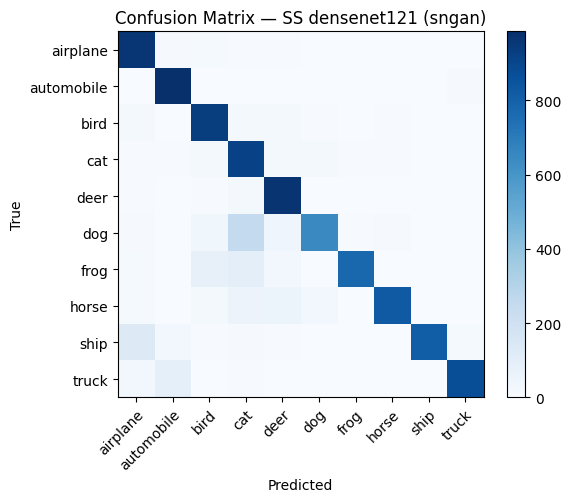

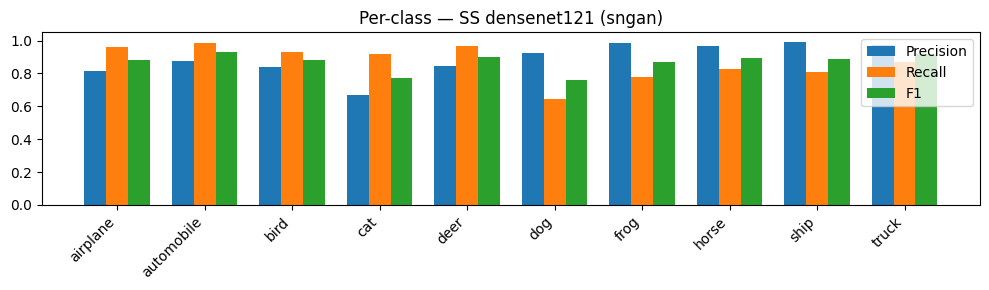

Updated: /content/drive/MyDrive/Imbalance/metrics/summary_sngan.csv


In [ ]:
# =====  Run the SNGAN-topup experiment =====
model_sngan, (y_true_sngan, y_pred_sngan) = run_sngan_experiment_SS_densenet()
